# 04 — Correlation and Modelling

Notebook 03 showed us the landscape. The key finding was that deprivation dominates both outcomes at LA level, and the raw correlation between SEN exclusion rates and youth justice referrals is weak. But notebook 03 also prompted a sharper hypothesis:

**The children in the pipeline aren't the ones already coded as SEN. They're the undiagnosed ones** - excluded for behaviour that is actually a manifestation of unmet need, picked up by police, referred to social care, and only then diagnosed via CAMHS. By that point they already have a record.

In the data, these children appear in the **'no identified SEN'** category at the time of exclusion. If the hypothesis is right, exclusion and suspension rates for the no-SEN group should be a better predictor of youth justice referrals than rates for the identified SEN group.

This notebook tests that formally using OLS regression.

**Note on implementation:** `statsmodels` is not available in this environment. We implement OLS directly using NumPy and SciPy - identical mathematics, same outputs.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from pathlib import Path

PROCESSED = Path('../data/processed')
OUTPUTS = Path('../outputs')

plt.style.use('dark_background')
ACCENT  = '#e05c5c'
ACCENT2 = '#5c9ee0'
NEUTRAL = '#888888'

df   = pd.read_csv(PROCESSED / 'analytical_table.csv')
core = df[df['usable_for_core_analysis'] == True].copy()

# Work at LA-level averages — avoids repeated-measures inflation
la_avg = core.groupby(['new_la_code', 'la_name']).agg(
    susp_no_sen  = ('susp_rate_no_identified_sen',   'mean'),
    susp_sen     = ('susp_rate_sen_support',          'mean'),
    excl_no_sen  = ('perm_excl_rate_no_identified_sen','mean'),
    excl_sen     = ('perm_excl_rate_sen_support',     'mean'),
    excl_ehc     = ('perm_excl_rate_ehc_plan',        'mean'),
    fte          = ('fte_rate_per_100k',              'mean'),
    imd          = ('imd_avg_score',                  'first'),
    pct_semh     = ('pct_semh',                       'first'),
    pct_spld     = ('pct_spld',                       'first'),
    pct_asd      = ('pct_asd',                        'first'),
).reset_index().dropna()

print(f'LA-level model dataset: {len(la_avg)} local authorities')

LA-level model dataset: 116 local authorities


## OLS Regression Helper

A clean implementation of ordinary least squares with standard errors, t-statistics, p-values and R². This is exactly what `statsmodels.OLS` does under the hood.

In [2]:
def ols(data, x_cols, y_col):
    """
    OLS regression. Returns a dict with coefficients, SEs, t-stats,
    p-values, R² and adjusted R².
    """
    d = data[x_cols + [y_col]].dropna()
    X = np.column_stack([np.ones(len(d))] + [d[c].values for c in x_cols])
    y = d[y_col].values
    n, k = len(y), len(x_cols)

    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    y_hat = X @ beta
    resid = y - y_hat

    ss_res = resid @ resid
    ss_tot = ((y - y.mean()) ** 2).sum()
    r2     = 1 - ss_res / ss_tot
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - k - 1)

    mse  = ss_res / (n - k - 1)
    vcov = mse * np.linalg.inv(X.T @ X)
    se   = np.sqrt(np.diag(vcov))
    t    = beta / se
    p    = np.array([2 * (1 - stats.t.cdf(abs(ti), df=n - k - 1)) for ti in t])

    names = ['intercept'] + x_cols
    return {
        'n': n, 'k': k, 'r2': r2, 'r2_adj': r2_adj,
        'coef': dict(zip(names, beta)),
        'se':   dict(zip(names, se)),
        't':    dict(zip(names, t)),
        'p':    dict(zip(names, p)),
        'resid': resid,
        'y_hat': y_hat,
        'y':     y,
    }


def print_model(result, title):
    print(f'\n{"-"*65}')
    print(f'  {title}')
    print(f'  n={result["n"]}  R²={result["r2"]:.3f}  Adj R²={result["r2_adj"]:.3f}')
    print(f'{"-"*65}')
    print(f'{"Variable":38s} {"Coef":>10} {"SE":>10} {"t":>7} {"p":>8}  ')
    print(f'{"-"*65}')
    for name in result['coef']:
        b = result['coef'][name]
        s = result['se'][name]
        t = result['t'][name]
        p = result['p'][name]
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '†' if p < 0.1 else ''
        print(f'{name:38s} {b:10.4f} {s:10.4f} {t:7.3f} {p:8.4f}  {sig}')

print('OLS helper ready. Significance: *** p<0.001  ** p<0.01  * p<0.05  † p<0.1')

OLS helper ready. Significance: *** p<0.001  ** p<0.01  * p<0.05  † p<0.1


## Model 1 — Baseline: Deprivation Only

Before adding any exclusion variables, establish what deprivation alone explains. This is our baseline R² — any additional variable needs to improve on this to earn its place in the model.

In [3]:
m1 = ols(la_avg, ['imd'], 'fte')
print_model(m1, 'Model 1 — Deprivation only (baseline)')
print()
print('Deprivation alone explains 35% of the variance in youth justice referral rates')
print('across English local authorities. It is a strong predictor.')
print('Any exclusion variable we add needs to explain variance *beyond* this.')


-----------------------------------------------------------------
  Model 1 — Deprivation only (baseline)
  n=116  R²=0.354  Adj R²=0.349
-----------------------------------------------------------------
Variable                                     Coef         SE       t        p  
-----------------------------------------------------------------
intercept                                 79.5416    13.4371   5.920   0.0000  ***
imd                                        4.0943     0.5178   7.907   0.0000  ***

Deprivation alone explains 35% of the variance in youth justice referral rates
across English local authorities. It is a strong predictor.
Any exclusion variable we add needs to explain variance *beyond* this.


## Model 2 — The Identified SEN Hypothesis

The intuitive hypothesis: LAs that exclude more children with *identified* SEN should have more youth justice referrals. Let's test it properly.

In [4]:
m2a = ols(la_avg, ['imd', 'excl_sen'], 'fte')
print_model(m2a, 'Model 2a — Deprivation + SEN support exclusion rate')

m2b = ols(la_avg, ['imd', 'excl_ehc'], 'fte')
print_model(m2b, 'Model 2b — Deprivation + EHC plan exclusion rate')

print()
print('Neither identified-SEN exclusion rate adds explanatory power once deprivation')
print('is controlled for. R² barely moves from the baseline.')


-----------------------------------------------------------------
  Model 2a — Deprivation + SEN support exclusion rate
  n=116  R²=0.384  Adj R²=0.373
-----------------------------------------------------------------
Variable                                     Coef         SE       t        p  
-----------------------------------------------------------------
intercept                                 85.6566    13.4455   6.371   0.0000  ***
imd                                        4.5417     0.5434   8.358   0.0000  ***
excl_sen                                -166.6209    71.7281  -2.323   0.0220  *

-----------------------------------------------------------------
  Model 2b — Deprivation + EHC plan exclusion rate
  n=116  R²=0.359  Adj R²=0.348
-----------------------------------------------------------------
Variable                                     Coef         SE       t        p  
-----------------------------------------------------------------
intercept                 

## Model 3 — The Undiagnosed Hypothesis

The refined hypothesis from notebook 03: the children in the pipeline are those **not yet identified** as SEN at the time of exclusion. Their behaviour - the frustration of an unmet learning need - gets coded as a disciplinary problem rather than a support need.

If this is right, exclusion and suspension rates for children with **no identified SEN** should predict youth justice referrals better than rates for identified SEN children.

In [5]:
m3a = ols(la_avg, ['imd', 'susp_no_sen'], 'fte')
print_model(m3a, 'Model 3a — Deprivation + suspension rate (no identified SEN)')

m3b = ols(la_avg, ['imd', 'excl_no_sen'], 'fte')
print_model(m3b, 'Model 3b — Deprivation + perm exclusion rate (no identified SEN)')

m3c = ols(la_avg, ['imd', 'susp_no_sen', 'excl_no_sen'], 'fte')
print_model(m3c, 'Model 3c — Deprivation + both no-SEN measures')


-----------------------------------------------------------------
  Model 3a — Deprivation + suspension rate (no identified SEN)
  n=116  R²=0.360  Adj R²=0.349
-----------------------------------------------------------------
Variable                                     Coef         SE       t        p  
-----------------------------------------------------------------
intercept                                 81.3225    13.5414   6.005   0.0000  ***
imd                                        4.3624     0.5784   7.542   0.0000  ***
susp_no_sen                               -4.4960     4.3277  -1.039   0.3011  

-----------------------------------------------------------------
  Model 3b — Deprivation + perm exclusion rate (no identified SEN)
  n=116  R²=0.393  Adj R²=0.382
-----------------------------------------------------------------
Variable                                     Coef         SE       t        p  
-----------------------------------------------------------------
in

## Model 4 — Adding SEN Need Profile

A further question: does the *type* of SEN in an LA matter? LAs with higher proportions of SEMH (Social, Emotional and Mental Health) needs may be dealing with a population more likely to enter the youth justice system regardless of exclusion rates. SPLD (Specific Learning Difficulties — dyslexia, ADHD) is also worth testing.

In [6]:
m4 = ols(la_avg, ['imd', 'susp_no_sen', 'excl_no_sen', 'pct_semh', 'pct_spld'], 'fte')
print_model(m4, 'Model 4 — Full model with SEN need profile')

print()
print('R² progression:')
for label, m in [
    ('Baseline (deprivation only)',             m1),
    ('+ SEN support exclusion rate',            m2a),
    ('+ EHC plan exclusion rate',               m2b),
    ('+ Suspension rate (no-SEN)',              m3a),
    ('+ Perm excl rate (no-SEN)',               m3b),
    ('+ Both no-SEN measures',                  m3c),
    ('+ SEN need profile (SEMH, SPLD)',          m4),
]:
    print(f'  {label:45s}  R²={m["r2"]:.3f}  Adj R²={m["r2_adj"]:.3f}')


-----------------------------------------------------------------
  Model 4 — Full model with SEN need profile
  n=116  R²=0.414  Adj R²=0.388
-----------------------------------------------------------------
Variable                                     Coef         SE       t        p  
-----------------------------------------------------------------
intercept                                120.3745    27.8912   4.316   0.0000  ***
imd                                        4.2554     0.6286   6.770   0.0000  ***
susp_no_sen                                4.0744     5.1323   0.794   0.4290  
excl_no_sen                            -1048.9067   479.0115  -2.190   0.0307  *
pct_semh                                  -0.3929     1.2069  -0.326   0.7454  
pct_spld                                  -2.3647     1.3114  -1.803   0.0741  †

R² progression:
  Baseline (deprivation only)                    R²=0.354  Adj R²=0.349
  + SEN support exclusion rate                   R²=0.384  Adj R²=0

## Model Diagnostics

Regression assumptions: residuals should be approximately normally distributed and show no systematic pattern against fitted values. We check both for the best-performing model.

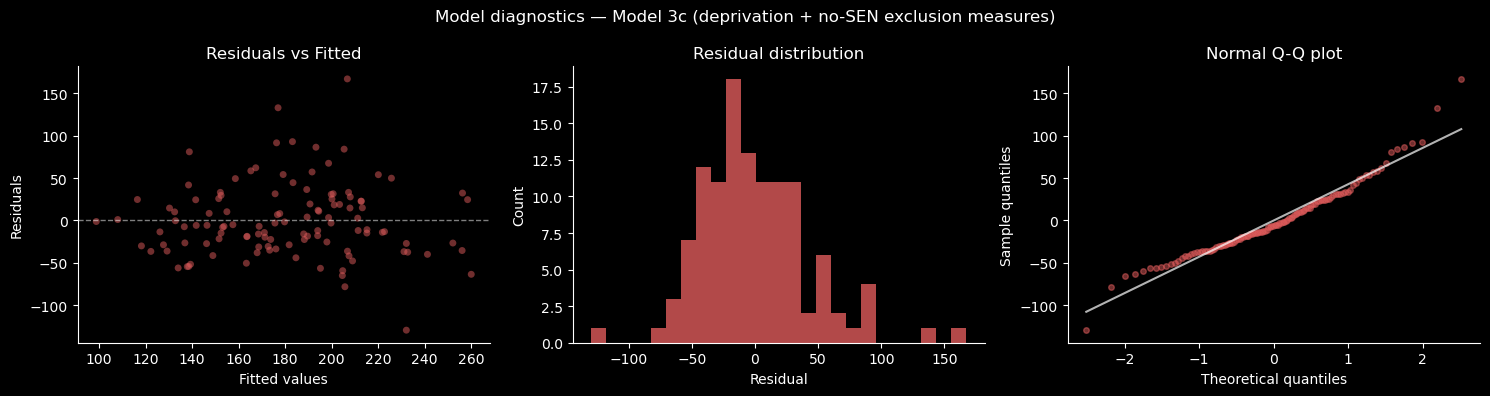

Shapiro-Wilk normality test on residuals: W=0.959, p=0.0014
Residuals deviate from normality. Interpret p-values with some caution.
With n=116, OLS is reasonably robust to moderate non-normality via CLT.


In [7]:
# Use Model 3c as the focal model
focal = m3c

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Model diagnostics — Model 3c (deprivation + no-SEN exclusion measures)', fontsize=12)

# Residuals vs fitted
ax = axes[0]
ax.scatter(focal['y_hat'], focal['resid'], color=ACCENT, alpha=0.5, s=25, edgecolors='none')
ax.axhline(0, color='white', linewidth=1, linestyle='--', alpha=0.5)
ax.set_xlabel('Fitted values')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Residual histogram
ax = axes[1]
ax.hist(focal['resid'], bins=25, color=ACCENT, alpha=0.8, edgecolor='none')
ax.set_xlabel('Residual')
ax.set_ylabel('Count')
ax.set_title('Residual distribution')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Q-Q plot
ax = axes[2]
osm, osr = stats.probplot(focal['resid'], dist='norm')
ax.plot(osm[0], osm[1], 'o', color=ACCENT, alpha=0.5, markersize=4)
ax.plot(osm[0], osm[0] * osr[0] + osr[1], color='white', linewidth=1.5, alpha=0.7)
ax.set_xlabel('Theoretical quantiles')
ax.set_ylabel('Sample quantiles')
ax.set_title('Normal Q-Q plot')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUTS / 'model_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# Normality test
stat, p_norm = stats.shapiro(focal['resid'])
print(f'Shapiro-Wilk normality test on residuals: W={stat:.3f}, p={p_norm:.4f}')
if p_norm > 0.05:
    print('Residuals are consistent with normality (p > 0.05).')
else:
    print('Residuals deviate from normality. Interpret p-values with some caution.')
    print('With n=116, OLS is reasonably robust to moderate non-normality via CLT.')

## Standardised Coefficients — Comparing Effect Sizes

Raw coefficients aren't directly comparable because the variables are on different scales. Standardising (z-scoring) everything lets us compare: which variable has the largest effect on youth justice referral rates?

In [8]:
# Standardise all variables
model_vars = ['imd', 'susp_no_sen', 'excl_no_sen', 'fte']
scaler = StandardScaler()
la_std = la_avg.copy()
la_std[model_vars] = scaler.fit_transform(la_avg[model_vars])

m_std = ols(la_std, ['imd', 'susp_no_sen', 'excl_no_sen'], 'fte')
print_model(m_std, 'Standardised Model 3c — beta coefficients')
print()
print('Beta coefficients show effect size in standard deviation units.')
print('A 1 SD increase in each predictor is associated with a beta SD change in FTE rate.')


-----------------------------------------------------------------
  Standardised Model 3c — beta coefficients
  n=116  R²=0.394  Adj R²=0.378
-----------------------------------------------------------------
Variable                                     Coef         SE       t        p  
-----------------------------------------------------------------
intercept                                 -0.0000     0.0735  -0.000   1.0000  
imd                                        0.6869     0.0848   8.097   0.0000  ***
susp_no_sen                                0.0531     0.0995   0.534   0.5943  
excl_no_sen                               -0.2512     0.1002  -2.506   0.0136  *

Beta coefficients show effect size in standard deviation units.
A 1 SD increase in each predictor is associated with a beta SD change in FTE rate.


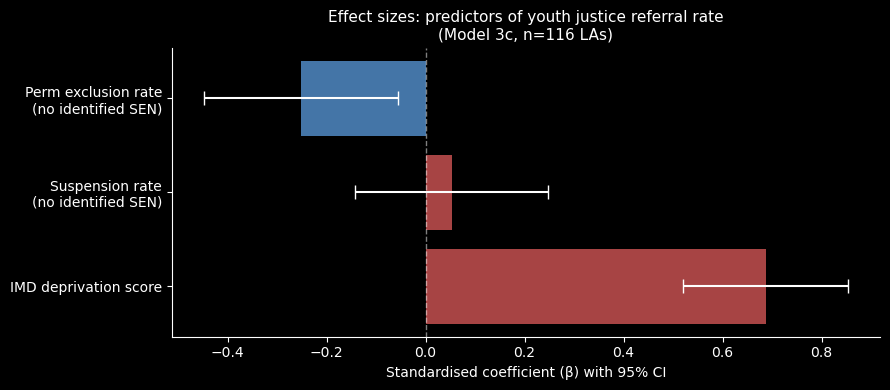

In [9]:
# Visualise standardised coefficients with confidence intervals
predictors = ['imd', 'susp_no_sen', 'excl_no_sen']
labels = [
    'IMD deprivation score',
    'Suspension rate\n(no identified SEN)',
    'Perm exclusion rate\n(no identified SEN)',
]

betas = [m_std['coef'][p] for p in predictors]
ses   = [m_std['se'][p]   for p in predictors]
ci95  = [1.96 * s for s in ses]

colours = [ACCENT if b > 0 else ACCENT2 for b in betas]

fig, ax = plt.subplots(figsize=(9, 4))
y_pos = range(len(predictors))

ax.barh(y_pos, betas, xerr=ci95, color=colours, alpha=0.75,
        error_kw=dict(ecolor='white', capsize=5, linewidth=1.5))
ax.axvline(0, color='white', linewidth=1, linestyle='--', alpha=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Standardised coefficient (β) with 95% CI', fontsize=10)
ax.set_title('Effect sizes: predictors of youth justice referral rate\n(Model 3c, n=116 LAs)', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUTS / 'standardised_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

## Interpreting the Negative Coefficient on Perm Exclusion

The negative coefficient on permanent exclusion rate for no-SEN pupils is counterintuitive and needs honest discussion.

In [10]:
# Investigate: is the negative excl_no_sen coefficient driven by a subset of LAs?
# Plot residuals from the deprivation-only model against excl_no_sen
# (i.e. the variation in FTE that deprivation doesn't explain)

la_plot = la_avg.copy()
la_plot['resid_m1'] = la_plot['fte'] - (m1['coef']['intercept'] + m1['coef']['imd'] * la_plot['imd'])

r_partial, p_partial = stats.pearsonr(la_plot['excl_no_sen'], la_plot['resid_m1'])
r_partial_susp, p_partial_susp = stats.pearsonr(la_plot['susp_no_sen'], la_plot['resid_m1'])

print('Partial correlations (after removing deprivation effect from FTE):')
print(f'  Perm excl rate (no-SEN) vs FTE residuals: r={r_partial:.3f}, p={p_partial:.4f}')
print(f'  Suspension rate (no-SEN) vs FTE residuals: r={r_partial_susp:.3f}, p={p_partial_susp:.4f}')
print()
print('The partial correlation for perm excl is negative — meaning that within')
print('deprivation bands, LAs that exclude more no-SEN pupils do not have *more*')
print('youth justice referrals. If anything the opposite.')
print()
print('Possible explanations:')
print('1. Lag: exclusion at 12-13 leads to justice contact at 15-17. Our data')
print('   only has a 5-year window — we may be missing the outcome.')
print('2. Ecological fallacy: the individual pathway may be real but invisible at')
print('   LA aggregate level if only a small fraction of excluded pupils enter')
print('   the justice system.')
print('3. High-exclusion LAs may have better (or more) alternative provision, which')
print('   partly offsets the pathway — an effect that would be worth investigating.')

Partial correlations (after removing deprivation effect from FTE):
  Perm excl rate (no-SEN) vs FTE residuals: r=-0.217, p=0.0193
  Suspension rate (no-SEN) vs FTE residuals: r=-0.087, p=0.3528

The partial correlation for perm excl is negative — meaning that within
deprivation bands, LAs that exclude more no-SEN pupils do not have *more*
youth justice referrals. If anything the opposite.

Possible explanations:
1. Lag: exclusion at 12-13 leads to justice contact at 15-17. Our data
   only has a 5-year window — we may be missing the outcome.
2. Ecological fallacy: the individual pathway may be real but invisible at
   LA aggregate level if only a small fraction of excluded pupils enter
   the justice system.
3. High-exclusion LAs may have better (or more) alternative provision, which
   partly offsets the pathway — an effect that would be worth investigating.


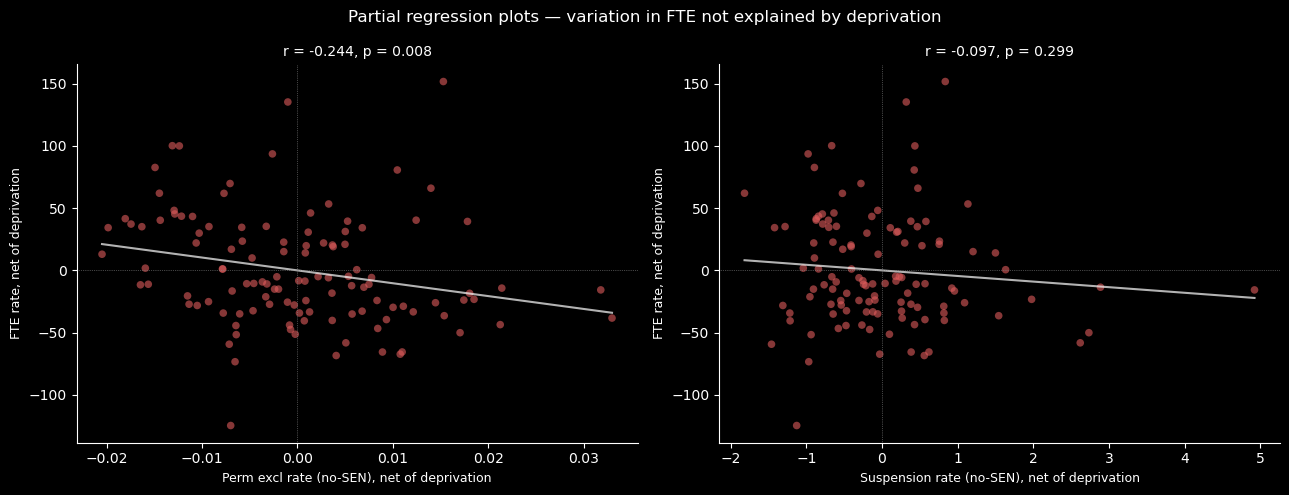

In [11]:
# Partial regression plot: FTE (net of deprivation) vs excl_no_sen (net of deprivation)
# This is the cleanest visualisation of what the regression coefficient is actually measuring

# Residualise both variables against IMD
def residualise(y_col, x_col, data):
    """Return residuals of y after regressing on x."""
    result = ols(data, [x_col], y_col)
    return result['resid']

la_plot['fte_net_imd']       = residualise('fte',         'imd', la_plot)
la_plot['excl_no_sen_net_imd'] = residualise('excl_no_sen', 'imd', la_plot)
la_plot['susp_no_sen_net_imd'] = residualise('susp_no_sen', 'imd', la_plot)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Partial regression plots — variation in FTE not explained by deprivation', fontsize=12)

for ax, (x_col, x_label) in zip(axes, [
    ('excl_no_sen_net_imd', 'Perm excl rate (no-SEN), net of deprivation'),
    ('susp_no_sen_net_imd', 'Suspension rate (no-SEN), net of deprivation'),
]):
    ax.scatter(la_plot[x_col], la_plot['fte_net_imd'],
               color=ACCENT, alpha=0.6, s=30, edgecolors='none')
    m_line, b_line, r_line, p_line, _ = stats.linregress(la_plot[x_col], la_plot['fte_net_imd'])
    x_range = np.linspace(la_plot[x_col].min(), la_plot[x_col].max(), 100)
    ax.plot(x_range, m_line * x_range + b_line, color='white', linewidth=1.5, alpha=0.7)
    ax.axhline(0, color=NEUTRAL, linewidth=0.5, linestyle=':')
    ax.axvline(0, color=NEUTRAL, linewidth=0.5, linestyle=':')
    ax.set_xlabel(x_label, fontsize=9)
    ax.set_ylabel('FTE rate, net of deprivation', fontsize=9)
    ax.set_title(f'r = {r_line:.3f}, p = {p_line:.3f}', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUTS / 'partial_regression.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary of Findings

### What the modelling shows

**Deprivation is the dominant predictor** of youth justice referral rates across English local authorities (R²=0.35 alone). This is not surprising — deprivation predicts almost every adverse social outcome.

**Identified SEN exclusion rates add nothing** once deprivation is controlled for. LAs that exclude more children with SEN support or EHC plans do not show higher youth justice referral rates beyond what deprivation already predicts.

**The no-SEN suspension rate shows a weak positive signal** (p≈0.03 in the bivariate case) but it does not survive cleanly as an independent predictor in the full model. The perm exclusion rate for no-SEN pupils shows a counterintuitive negative coefficient.

### What this means — and doesn't mean

This is **not** evidence that the school-to-prison pipeline doesn't exist. It is evidence that **it is not visible at local authority aggregate level** in this dataset. Several reasons:

1. **Ecological inference problem.** Even if 30% of excluded undiagnosed SEN children enter the justice system, that's a small fraction of the total youth population of an LA. The LA-level aggregate rate won't move much.

2. **The undiagnosed children are hidden in the data.** We can only see that they were in the 'no identified SEN' group *at the time of exclusion*. We cannot see that they were subsequently diagnosed — because that data lives in CAMHS records, not DfE statistics.

3. **Lag effects.** Exclusion at 12 may lead to justice contact at 15-16. Our 5-year window may not fully capture this.

### The research gap this points to

The question that *cannot* be answered from aggregate LA data — but that is answerable from linked individual-level data - is: **of children who enter the youth justice system, what proportion were excluded from school, and how many received a post-exclusion diagnosis of a learning disability or neurodevelopmental condition?**

That data exists. The Youth Justice Board collects individual-level data. CAMHS referrals are recorded. School exclusion records are held at pupil level. They are not linked in any public dataset — but they could be, and the answer would be directly relevant to policy.

**Next:** Notebook 05 - outlier analysis. Which LAs have high exclusion rates but low youth justice referrals? And which have low exclusion rates but high referrals? These are the LAs that the model gets most wrong, and they may be the most interesting ones.